# Step by Step Fact Checking 

This code runs a step-by-step Fact Checking pipeline 

In [ ]:
import sys

sys.path.append("..")

In [ ]:
from dotenv import load_dotenv

load_dotenv(".env")

In [ ]:
import json
from textwrap import wrap

from IPython.display import HTML, display

from veridika.src.workflows.StepwiseWorkflows import (
    CrititalQuestionRefinementWorkflow,
    CrititalQuestionWorkflow,
    FactCheckingWorkflow,
    GenSearchesWorkflow,
    ImageGenerationWorkflow,
    SourceRefinementWorkflow,
)

In [2]:
statement = "Los coches eléctricos son más contaminantes que los coches de gasolina"
language = "es"
location = "es"

## Critical questions generation

In [3]:
critical_question_workflow = CrititalQuestionWorkflow()
critical_questions, cost = await critical_question_workflow.run(
    statement=statement,
    language=language,
    location=location,
    model="google/gemini-2.5-flash",
)
print(json.dumps(critical_questions, indent=4, ensure_ascii=False))
print(f"💰 Step cost: {cost}")

{
    "questions": [
        "¿Cuáles son las emisiones de carbono promedio en la producción de un coche eléctrico (incluyendo la batería) en comparación con la producción de un coche de gasolina en 2025?",
        "¿Qué estudios de análisis de ciclo de vida (LCA) publicados entre 2020 y 2025 comparan el impacto ambiental total de los coches eléctricos y los coches de gasolina?",
        "¿Cuál es la huella de carbono de la generación de electricidad para cargar un coche eléctrico en países con diferentes mezclas energéticas (por ejemplo, con alta o baja proporción de energías renovables)?",
        "¿Qué opinan las principales agencias medioambientales (como la Agencia Europea de Medio Ambiente o la EPA de EE. UU.) sobre la comparación del impacto ambiental total de coches eléctricos y de gasolina?",
        "¿Existe alguna evidencia o estudio reciente (2020-2025) que sugiera que los coches eléctricos son más contaminantes en general que los coches de gasolina, considerando todo su ci

#### Critical question refinement

In [4]:
critial_question_refinement_workflow = CrititalQuestionRefinementWorkflow()
refinement = "También quiero que consideres la contaminación del proceso de reciclaje de la batería"
new_critical_questions, cost = await critial_question_refinement_workflow.run(
    questions=critical_questions["questions"],
    input=statement,
    refinement=refinement,
    language=language,
    location=location,
    model="google/gemini-2.5-flash",
)
print(json.dumps(new_critical_questions, indent=4, ensure_ascii=False))
print(f"💰 Step cost: {cost}")

{
    "questions": [
        "¿Cuáles son las emisiones de carbono promedio en la producción de un coche eléctrico (incluyendo la batería) en comparación con la producción de un coche de gasolina en 2025?",
        "¿Qué estudios de análisis de ciclo de vida (LCA) publicados entre 2020 y 2025 comparan el impacto ambiental total de los coches eléctricos y los coches de gasolina?",
        "¿Cuál es la huella de carbono de la generación de electricidad para cargar un coche eléctrico en países con diferentes mezclas energéticas (por ejemplo, con alta o baja proporción de energías renovables)?",
        "¿Qué opinan las principales agencias medioambientales (como la Agencia Europea de Medio Ambiente o la EPA de EE. UU.) sobre la comparación del impacto ambiental total de coches eléctricos y de gasolina?",
        "¿Existe alguna evidencia o estudio reciente (2020-2025) que sugiera que los coches eléctricos son más contaminantes en general que los coches de gasolina, considerando todo su ci

# Web Search

In [5]:
gen_searches_workflow = GenSearchesWorkflow()
sources, searches, cost = await gen_searches_workflow.run(
    statement=statement,
    questions=new_critical_questions["questions"],
    language=language,
    location=location,
    model="google/gemini-2.5-flash",
)


def display_sources(sources):
    for element in sources:
        link = element["link"]
        snippet = element["snippet"]
        favicon = element["favicon"]
        title = element["title"]

        # Create HTML with embedded favicon image
        favicon_html = (
            f'<img src="{favicon}" width="16" height="16" style="vertical-align: middle; margin-right: 5px;">'
            if favicon
            else "🌐"
        )

        html_output = f"""
        <div style="border: 1px solid #ddd; padding: 15px; margin: 10px 0; border-radius: 5px; background-color: #f9f9f9;">
            <div style="font-weight: bold; font-size: 16px; margin-bottom: 10px;">
                {favicon_html} {title}
            </div>
            <div style="color: #1a0dab; margin-bottom: 8px; word-wrap: break-word;">
                🔗 <a href="{link}" target="_blank">{link if link else "N/A"}</a>
            </div>
            <div style="color: #545454; line-height: 1.5;">
                {snippet}
            </div>
        </div>
        """

        display(HTML(html_output))


for search in searches:
    print(search)

print()

display_sources(sources)
print(f"💰 Step cost: {cost}")

emisiones carbono producción coche eléctrico vs gasolina 2025 estudio
análisis ciclo vida coche eléctrico gasolina 2020-2025 impacto ambiental
huella carbono electricidad coche eléctrico mezcla energética países europeos 2025
agencia europea medio ambiente impacto ambiental coches eléctricos vs gasolina declaración
reciclaje baterías coche eléctrico impacto ambiental 2025 desafíos



💰 Step cost: 0.0055707000000000005


#### Critical question refinement

In [6]:
source_refinement_workflow = SourceRefinementWorkflow()
user_feedback = "Quiero que también busques información oficial de la Union Europea o algún comunicado de prensa de la Union Europea"
new_sources, new_searches, cost = await source_refinement_workflow.run(
    statement=statement,
    current_searches=searches,
    language=language,
    location=location,
    model="google/gemini-2.5-flash",
    user_feedback=user_feedback,
)

for search in new_searches:
    print(search)

display_sources(new_sources)
print(f"💰 Step cost: {cost}")

Unión Europea comunicado prensa coches eléctricos vs gasolina impacto ambiental 2025


💰 Step cost: 0.0013946


In [7]:
sources = sources + new_sources
searches = searches + new_searches

# Fact checking Article

In [8]:
article_fact_checking_workflow = FactCheckingWorkflow()
result, cost = await article_fact_checking_workflow.run(
    question=new_critical_questions["questions"],
    statement=statement,
    language=language,
    location=location,
    sources=sources,
    model="google/gemini-2.5-flash",
    use_rag=True,
    embedding_model="gemini-embedding-001",
    article_writer_model="google/gemini-2.5-flash",
    question_answer_model="google/gemini-2.5-flash",
    metadata_model="google/gemini-2.5-flash",
)

print(f"✅ Label: {result['metadata']['label']}")
print(f"📚 Sources used: {len(result['sources'])}")
print("\n".join(wrap(result["answer"], width=150)))

print(f"📊 Metadata: {json.dumps(result['metadata'], indent=4, ensure_ascii=False)}")
print(f"💰 Step cost: {cost}")

✅ Label: Fake
📚 Sources used: 11
Se han presentado varios argumentos que sugieren que los coches eléctricos pueden ser más contaminantes que los coches de gasolina, especialmente en
ciertas fases de su ciclo de vida. **La producción de un vehículo eléctrico, particularmente la fabricación de sus baterías, genera un mayor volumen
de emisiones iniciales en comparación con un coche de gasolina o diésel** [1]. Específicamente, en la **fabricación del vehículo eléctrico, las
emisiones de CO2 pueden ser hasta una tonelada mayores que en un vehículo de combustión, sin incluir la batería** [2]. Si se considera el motor y el
inversor de un vehículo eléctrico, estos emiten más CO2 que el motor y la transmisión de un vehículo de combustión interna, con una **diferencia de
173 kg de CO2 más que un vehículo diésel y 437 kg más que un vehículo de gasolina** [2]. Esto se basa en estudios que muestran que la producción de
piezas específicas del vehículo eléctrico (sin contar las baterías) genera más e

# Image Generation

💰 Step cost: 0.0031064



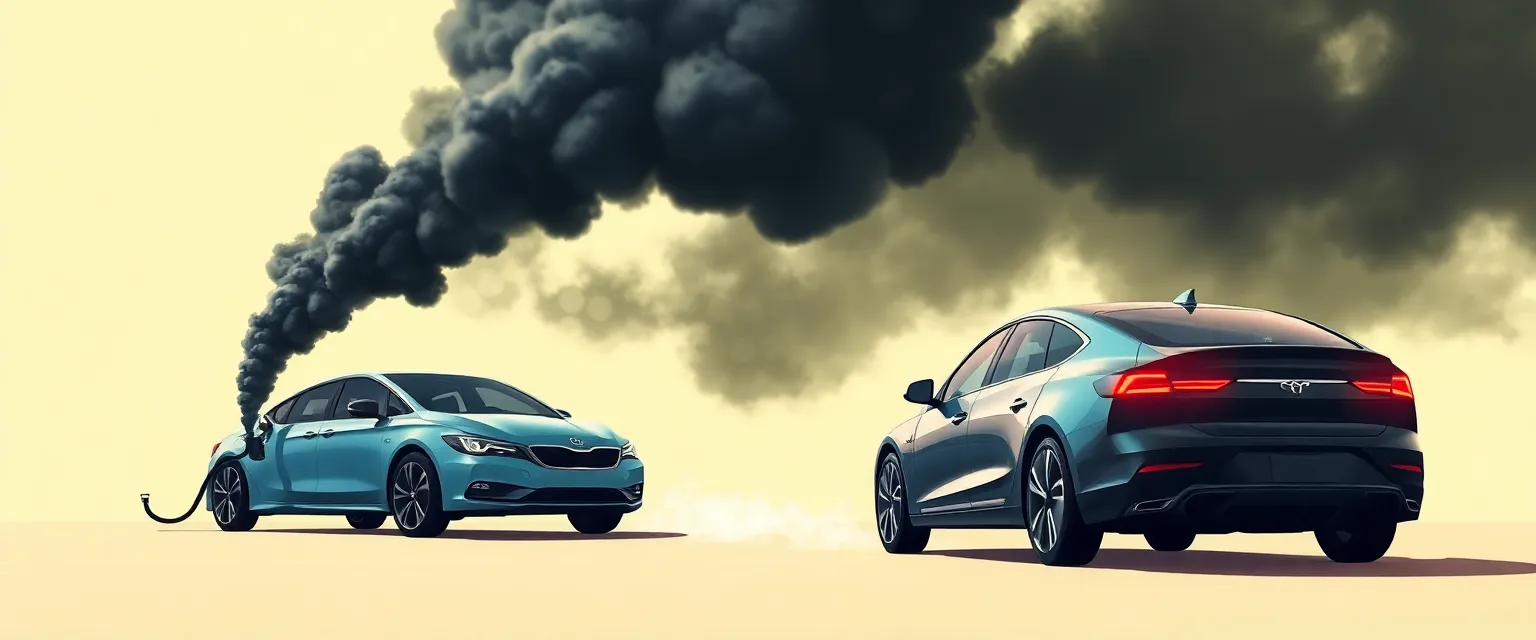

In [ ]:
import base64
import mimetypes

import requests

image_generation_workflow = ImageGenerationWorkflow()
image_result, cost = await image_generation_workflow.run(
    statement=statement,
    model="google/gemini-2.5-flash",
)

# Show cost
print(f"💰 Step cost: {cost}")

# Display image from either base64 data URL or remote URL (in-memory only)


img_value = image_result.get("image_url")
if not img_value:
    print("No image returned.")
else:
    try:
        if isinstance(img_value, str) and img_value.startswith("data:"):
            # Already a data URL (e.g., data:image/png;base64,...) -> display directly
            display(HTML(f'<img src="{img_value}" style="max-width:100%;"/>'))
        elif isinstance(img_value, str):
            # Remote URL -> download in memory and embed as data URL
            resp = requests.get(img_value, timeout=60)
            resp.raise_for_status()
            mime = (
                resp.headers.get("Content-Type")
                or mimetypes.guess_type(img_value)[0]
                or "image/png"
            )
            b64 = base64.b64encode(resp.content).decode("ascii")
            data_url = f"data:{mime};base64,{b64}"
            display(HTML(f'<img src="{data_url}" style="max-width:100%;"/>'))
        else:
            print(f"Unexpected image value type: {type(img_value)}")
    except Exception as e:
        print(f"Failed to display image: {e}")